# Model Evaluation
**Date:** May 20, 2026

All four models are evaluated together:
- Linear Regression
- Random Forest
- Gradient Boosting
- LSTM
- Baseline (Naive)

Metrics used:
- RMSE — Root Mean Squared Error
- MAE  — Mean Absolute Error
- R²   — R-squared Score
- Accuracy, Precision, Recall — Direction prediction (up/down)

## STEP 1 — Import Evaluation Libraries

In [1]:
import pandas as pd
import numpy as np
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score,
    accuracy_score,
    precision_score,
    recall_score,
    classification_report
)
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt
import joblib
import os
import warnings
warnings.filterwarnings('ignore')
print('Libraries imported successfully.')

Libraries imported successfully.


## STEP 2 — Load Prediction Files

In [2]:
lr_df   = pd.read_csv('stock_datasets/lr_predictions.csv')
rf_df   = pd.read_csv('stock_datasets/rf_predictions.csv')
gb_df   = pd.read_csv('stock_datasets/gb_predictions.csv')
lstm_df = pd.read_csv('stock_datasets/lstm_predictions.csv')

print(f'LR   rows: {len(lr_df)}')
print(f'RF   rows: {len(rf_df)}')
print(f'GB   rows: {len(gb_df)}')
print(f'LSTM rows: {len(lstm_df)}')

LR   rows: 548
RF   rows: 548
GB   rows: 548
LSTM rows: 546


## STEP 3 — Extract Actual and Predicted Values

#### Linear Regression

In [3]:
y_test_lr = lr_df['Actual']
y_pred_lr = lr_df['Predicted']

#### Random Forest

In [4]:
y_test_rf = rf_df['Actual']
y_pred_rf = rf_df['Predicted']

#### Gradient Boosting

In [5]:
y_test_gb = gb_df['Actual']
y_pred_gb = gb_df['Predicted']

#### LSTM

In [6]:
y_test_lstm_scaled = lstm_df['Actual'].values.reshape(-1, 1)
y_pred_lstm_scaled = lstm_df['Predicted'].values.reshape(-1, 1)

## STEP 4 — LSTM: Inverse Transform to Original Price Scale

LSTM predictions are stored in the scaled [0, 1] range. All metrics must be computed in the original INR price scale so they are directly comparable with the other models. The saved MinMaxScaler from preprocessing is loaded; if not found a fallback refits on the raw close price series.

In [7]:
scaler_path = 'stock_datasets/scaler_lstm.pkl'

if os.path.exists(scaler_path):
    scaler = joblib.load(scaler_path)
    print('LSTM scaler loaded from', scaler_path)
else:
    lstm_raw = pd.read_csv('stock_datasets/RELIANCE_lstm_unscaled.csv')
    scaler   = MinMaxScaler(feature_range=(0, 1))
    scaler.fit_transform(lstm_raw[['Close']])
    print('LSTM scaler refitted from raw CSV (fallback).')

y_test_lstm = scaler.inverse_transform(y_test_lstm_scaled).flatten()
y_pred_lstm = scaler.inverse_transform(y_pred_lstm_scaled).flatten()

print(f'Actual  price range: {y_test_lstm.min():.2f} – {y_test_lstm.max():.2f} INR')
print(f'Predicted price range: {y_pred_lstm.min():.2f} – {y_pred_lstm.max():.2f} INR')

LSTM scaler loaded from stock_datasets/scaler_lstm.pkl
Actual  price range: 1157.28 – 1592.30 INR
Predicted price range: 1207.45 – 1541.29 INR


## STEP 5 — Baseline (Naive) Model

The Naive model predicts that tomorrow's price equals today's price (`y_pred[t] = y_actual[t-1]`). This is the standard time-series benchmark — any model claiming predictive value must outperform it.

In [8]:
y_test_base = y_test_lr.values[1:]
y_pred_base = y_test_lr.values[:-1]

print(f'Baseline test samples: {len(y_test_base)}')
print(f'Sample — actual: {y_test_base[0]:.2f}  predicted: {y_pred_base[0]:.2f}')

Baseline test samples: 547
Sample — actual: 1437.41  predicted: 1343.13


## STEP 6 — Evaluate Linear Regression

In [9]:
rmse_lr = np.sqrt(mean_squared_error(y_test_lr, y_pred_lr))
mae_lr  = mean_absolute_error(y_test_lr, y_pred_lr)
r2_lr   = r2_score(y_test_lr, y_pred_lr)

print('Linear Regression')
print('RMSE:', rmse_lr)
print('MAE :', mae_lr)
print('R2  :', r2_lr)

Linear Regression
RMSE: 19.358079283305262
MAE : 13.991521787332513
R2  : 0.9611586430902465


## STEP 7 — Evaluate Random Forest

In [10]:
rmse_rf = np.sqrt(mean_squared_error(y_test_rf, y_pred_rf))
mae_rf  = mean_absolute_error(y_test_rf, y_pred_rf)
r2_rf   = r2_score(y_test_rf, y_pred_rf)

print('Random Forest')
print('RMSE:', rmse_rf)
print('MAE :', mae_rf)
print('R2  :', r2_rf)

Random Forest
RMSE: 107.17562909518901
MAE : 86.49960067192134
R2  : -0.1905892248719503


## STEP 8 — Evaluate Gradient Boosting

In [11]:
rmse_gb = np.sqrt(mean_squared_error(y_test_gb, y_pred_gb))
mae_gb  = mean_absolute_error(y_test_gb, y_pred_gb)
r2_gb   = r2_score(y_test_gb, y_pred_gb)

print('Gradient Boosting')
print('RMSE:', rmse_gb)
print('MAE :', mae_gb)
print('R2  :', r2_gb)

Gradient Boosting
RMSE: 104.76807131859299
MAE : 84.9303262604085
R2  : -0.13770001296843204


## STEP 9 — Evaluate LSTM (Inverse Transformed)

In [12]:
rmse_lstm = np.sqrt(mean_squared_error(y_test_lstm, y_pred_lstm))
mae_lstm  = mean_absolute_error(y_test_lstm, y_pred_lstm)
r2_lstm   = r2_score(y_test_lstm, y_pred_lstm)

print('LSTM (INR scale)')
print('RMSE:', rmse_lstm)
print('MAE :', mae_lstm)
print('R2  :', r2_lstm)

LSTM (INR scale)
RMSE: 40.790926358180315
MAE : 32.79672954627725
R2  : 0.8280112562494462


## STEP 10 — Evaluate Baseline (Naive)

In [13]:
rmse_base = np.sqrt(mean_squared_error(y_test_base, y_pred_base))
mae_base  = mean_absolute_error(y_test_base, y_pred_base)
r2_base   = r2_score(y_test_base, y_pred_base)

print('Baseline (Naive)')
print('RMSE:', rmse_base)
print('MAE :', mae_base)
print('R2  :', r2_base)

Baseline (Naive)
RMSE: 19.17872828033919
MAE : 13.816799910020567
R2  : 0.9619189503836505


## STEP 11 — Regression Metrics Comparison Table

In [14]:
reg_results = pd.DataFrame({
    'Model': [
        'Linear Regression',
        'Random Forest',
        'Gradient Boosting',
        'LSTM',
        'Baseline (Naive)'
    ],
    'RMSE': [
        round(rmse_lr,   4),
        round(rmse_rf,   4),
        round(rmse_gb,   4),
        round(rmse_lstm, 4),
        round(rmse_base, 4)
    ],
    'MAE': [
        round(mae_lr,   4),
        round(mae_rf,   4),
        round(mae_gb,   4),
        round(mae_lstm, 4),
        round(mae_base, 4)
    ],
    'R2 Score': [
        round(r2_lr,   4),
        round(r2_rf,   4),
        round(r2_gb,   4),
        round(r2_lstm, 4),
        round(r2_base, 4)
    ]
})

print(reg_results.to_string(index=False))

            Model     RMSE     MAE  R2 Score
Linear Regression  19.3581 13.9915    0.9612
    Random Forest 107.1756 86.4996   -0.1906
Gradient Boosting 104.7681 84.9303   -0.1377
             LSTM  40.7909 32.7967    0.8280
 Baseline (Naive)  19.1787 13.8168    0.9619


## STEP 12 — Classification Metrics: Accuracy, Precision, Recall

**Project Objective 2** requires accuracy, precision, and recall. These are classification metrics, so the regression predictions are converted into a binary direction signal:

- **Class 1 (Up):** next-day price > today's price
- **Class 0 (Down/Flat):** next-day price ≤ today's price

This measures whether each model correctly predicts the *direction* of price movement — which is what matters most for trading decisions.

In [15]:
def price_to_direction(actual, predicted):
    actual    = np.array(actual)
    predicted = np.array(predicted)
    # Direction vs previous actual day
    actual_dir = (actual[1:]    > actual[:-1]).astype(int)
    pred_dir   = (predicted[1:] > actual[:-1]).astype(int)
    return actual_dir, pred_dir


def clf_metrics(y_true, y_pred, name):
    a_dir, p_dir = price_to_direction(y_true, y_pred)
    return {
        'Model':     name,
        'Accuracy':  round(accuracy_score(a_dir, p_dir),                        4),
        'Precision': round(precision_score(a_dir, p_dir, zero_division=0),      4),
        'Recall':    round(recall_score(a_dir, p_dir,    zero_division=0),      4)
    }


clf_results = pd.DataFrame([
    clf_metrics(y_test_lr,   y_pred_lr,   'Linear Regression'),
    clf_metrics(y_test_rf,   y_pred_rf,   'Random Forest'),
    clf_metrics(y_test_gb,   y_pred_gb,   'Gradient Boosting'),
    clf_metrics(y_test_lstm, y_pred_lstm, 'LSTM'),
    clf_metrics(y_test_base, y_pred_base, 'Baseline (Naive)'),
])

print('=== Classification Metrics (Direction Prediction) ===')
print(clf_results.to_string(index=False))

=== Classification Metrics (Direction Prediction) ===
            Model  Accuracy  Precision  Recall
Linear Regression    0.4881     0.4948  0.6884
    Random Forest    0.4918     0.4853  0.1196
Gradient Boosting    0.4899     0.4651  0.0725
             LSTM    0.5229     0.5330  0.4400
 Baseline (Naive)    0.4963     0.0000  0.0000


### Detailed Classification Report — Linear Regression

The detailed report shows per-class precision, recall, F1-score and support for the best-performing model.

In [16]:
a_dir_lr, p_dir_lr = price_to_direction(y_test_lr, y_pred_lr)
print('=== Linear Regression — Classification Report ===')
print(classification_report(
    a_dir_lr, p_dir_lr,
    target_names=['Down (0)', 'Up (1)']
))

=== Linear Regression — Classification Report ===
              precision    recall  f1-score   support

    Down (0)       0.47      0.28      0.35       271
      Up (1)       0.49      0.69      0.58       276

    accuracy                           0.49       547
   macro avg       0.48      0.49      0.47       547
weighted avg       0.48      0.49      0.47       547



## STEP 13 — Full Comparison Table (All Metrics)

In [17]:
final_table = reg_results.merge(clf_results, on='Model')

print('=== FINAL MODEL COMPARISON TABLE ===')
print(final_table.to_string(index=False))

final_table.to_csv(
    'stock_datasets/model_evaluation_results.csv',
    index=False
)
print('\nSaved to stock_datasets/model_evaluation_results.csv')

=== FINAL MODEL COMPARISON TABLE ===
            Model     RMSE     MAE  R2 Score  Accuracy  Precision  Recall
Linear Regression  19.3581 13.9915    0.9612    0.4881     0.4948  0.6884
    Random Forest 107.1756 86.4996   -0.1906    0.4918     0.4853  0.1196
Gradient Boosting 104.7681 84.9303   -0.1377    0.4899     0.4651  0.0725
             LSTM  40.7909 32.7967    0.8280    0.5229     0.5330  0.4400
 Baseline (Naive)  19.1787 13.8168    0.9619    0.4963     0.0000  0.0000

Saved to stock_datasets/model_evaluation_results.csv


## STEP 14 — RMSE, MAE, R² Comparison Plots

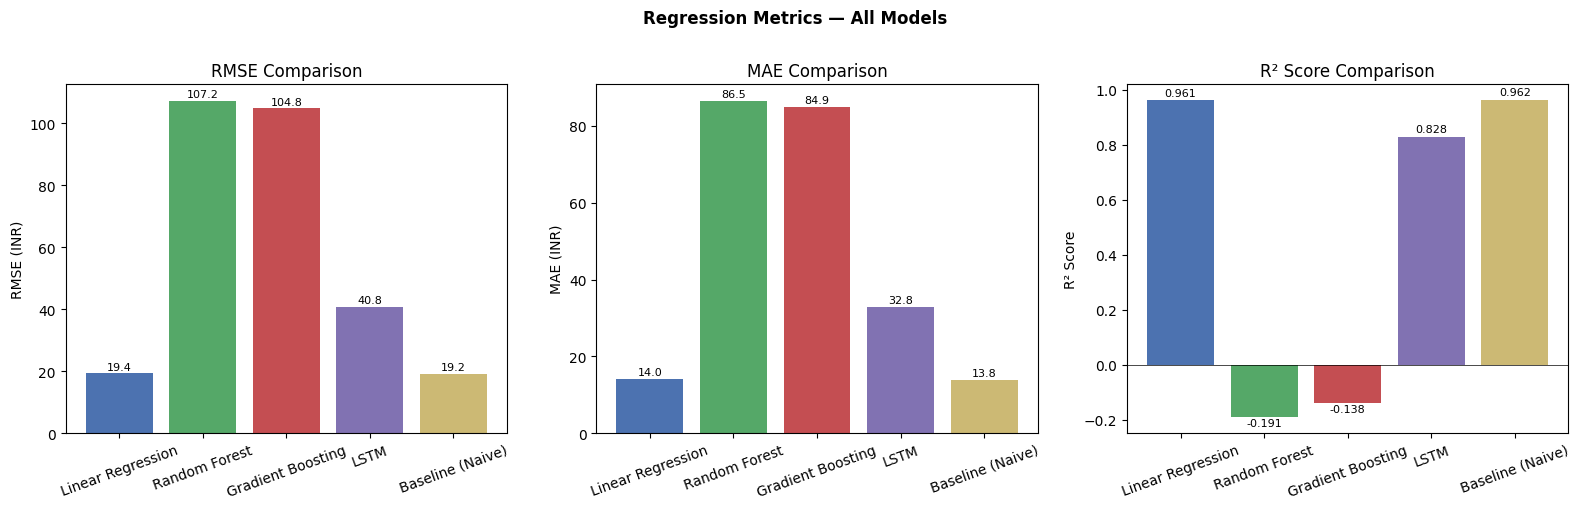

Regression metrics plot saved.


In [18]:
models = final_table['Model']
colors = ['#4C72B0', '#55A868', '#C44E52', '#8172B2', '#CCB974']

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# RMSE
axes[0].bar(models, final_table['RMSE'], color=colors)
axes[0].set_title('RMSE Comparison')
axes[0].set_ylabel('RMSE (INR)')
axes[0].tick_params(axis='x', rotation=20)
for i, v in enumerate(final_table['RMSE']):
    axes[0].text(i, v + 0.5, f'{v:.1f}',
                 ha='center', va='bottom', fontsize=8)

# MAE
axes[1].bar(models, final_table['MAE'], color=colors)
axes[1].set_title('MAE Comparison')
axes[1].set_ylabel('MAE (INR)')
axes[1].tick_params(axis='x', rotation=20)
for i, v in enumerate(final_table['MAE']):
    axes[1].text(i, v + 0.5, f'{v:.1f}',
                 ha='center', va='bottom', fontsize=8)

# R2
axes[2].bar(models, final_table['R2 Score'], color=colors)
axes[2].set_title('R² Score Comparison')
axes[2].set_ylabel('R² Score')
axes[2].tick_params(axis='x', rotation=20)
axes[2].axhline(y=0, color='black', linewidth=0.5)
for i, v in enumerate(final_table['R2 Score']):
    offset = 0.01 if v >= 0 else -0.04
    axes[2].text(i, v + offset, f'{v:.3f}',
                 ha='center', va='bottom', fontsize=8)

plt.suptitle('Regression Metrics — All Models', fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(
    'stock_datasets/regression_metrics_comparison.png',
    dpi=150, bbox_inches='tight'
)
plt.show()
print('Regression metrics plot saved.')

## STEP 15 — Accuracy, Precision, Recall Comparison Plots

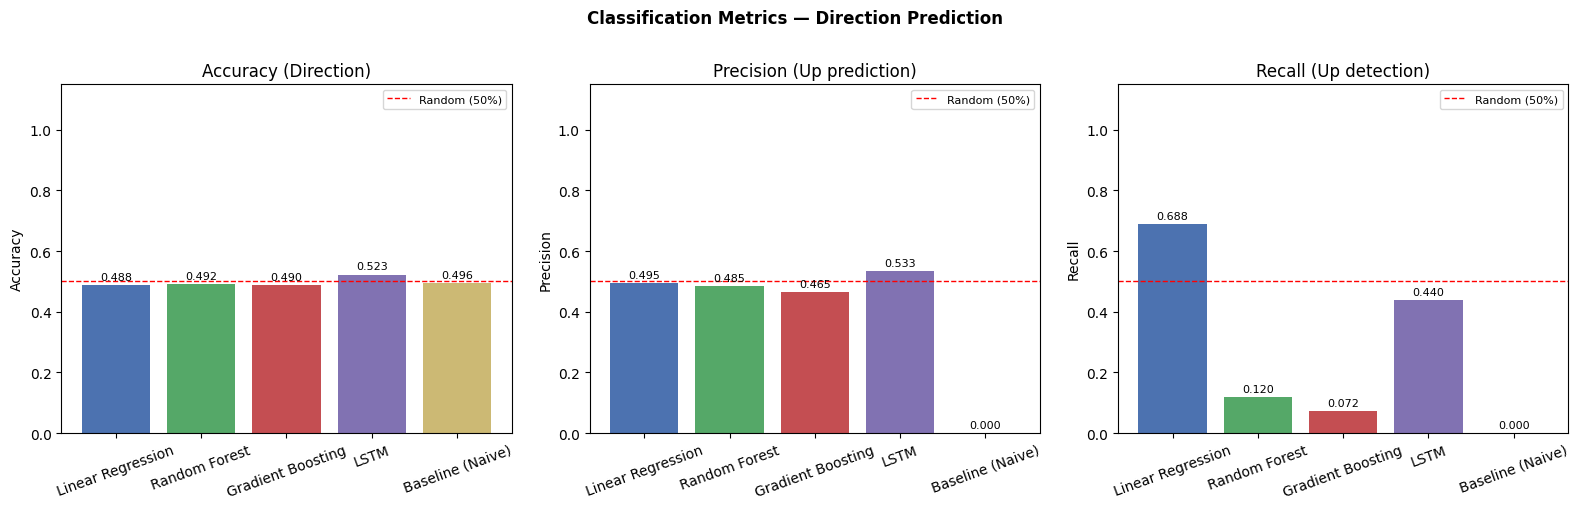

Classification metrics plot saved.


In [19]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
metrics = ['Accuracy', 'Precision', 'Recall']
titles  = [
    'Accuracy (Direction)',
    'Precision (Up prediction)',
    'Recall (Up detection)'
]

for ax, metric, title in zip(axes, metrics, titles):
    ax.bar(models, clf_results[metric], color=colors)
    ax.set_title(title)
    ax.set_ylabel(metric)
    ax.set_ylim(0, 1.15)
    ax.tick_params(axis='x', rotation=20)
    ax.axhline(
        y=0.5, color='red', linewidth=1,
        linestyle='--', label='Random (50%)'
    )
    ax.legend(fontsize=8)
    for i, v in enumerate(clf_results[metric]):
        ax.text(i, v + 0.01, f'{v:.3f}',
                ha='center', va='bottom', fontsize=8)

plt.suptitle(
    'Classification Metrics — Direction Prediction',
    fontweight='bold', y=1.01
)
plt.tight_layout()
plt.savefig(
    'stock_datasets/classification_metrics_comparison.png',
    dpi=150, bbox_inches='tight'
)
plt.show()
print('Classification metrics plot saved.')

## STEP 16 — Actual vs Predicted Plots

### Linear Regression

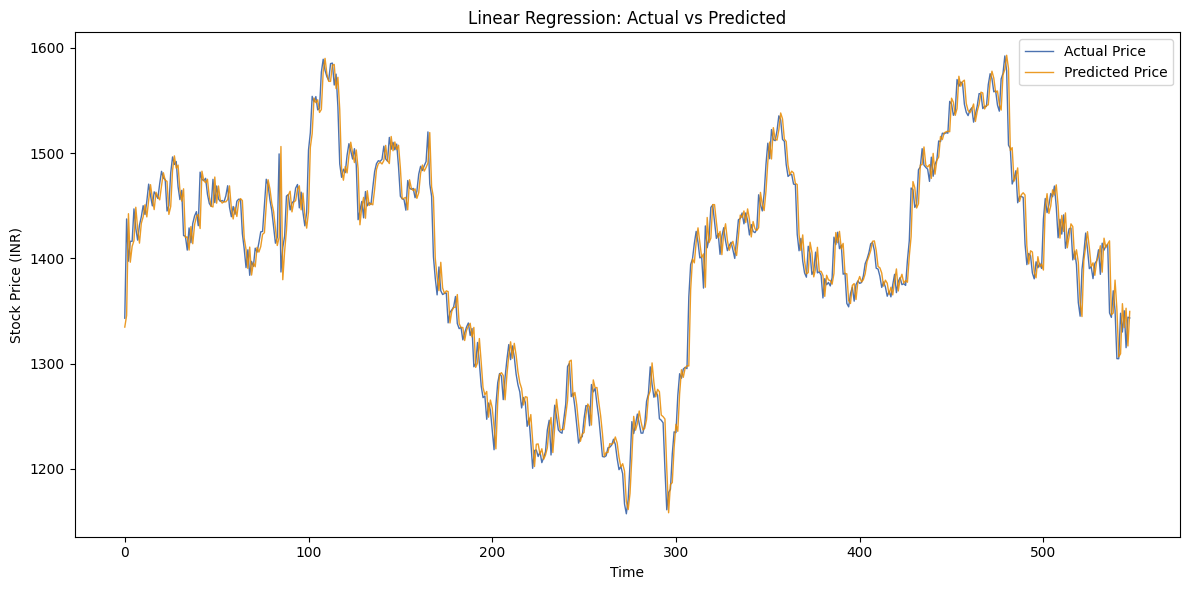

In [20]:
plt.figure(figsize=(12, 6))
plt.plot(y_test_lr.values,  label='Actual Price',    color='#4C72B0', linewidth=1)
plt.plot(y_pred_lr.values,  label='Predicted Price', color='#E88A00', linewidth=1, alpha=0.85)
plt.title('Linear Regression: Actual vs Predicted')
plt.xlabel('Time')
plt.ylabel('Stock Price (INR)')
plt.legend()
plt.tight_layout()
plt.savefig(
    'stock_datasets/lr_actual_vs_predicted.png',
    dpi=150, bbox_inches='tight'
)
plt.show()

### Random Forest

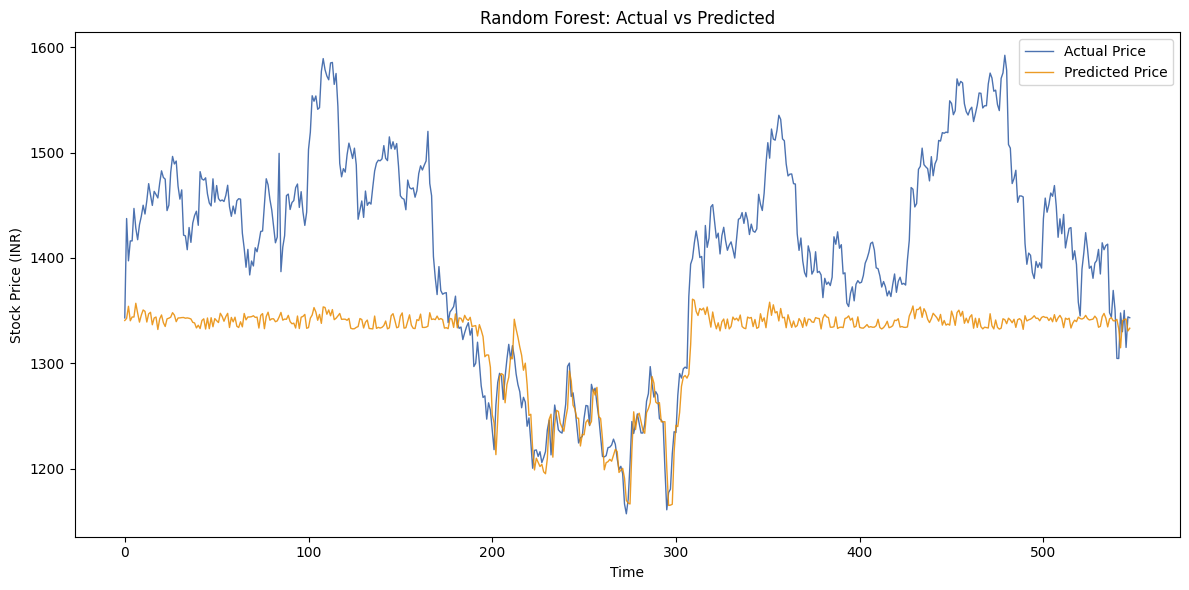

In [21]:
plt.figure(figsize=(12, 6))
plt.plot(y_test_rf.values,  label='Actual Price',    color='#4C72B0', linewidth=1)
plt.plot(y_pred_rf.values,  label='Predicted Price', color='#E88A00', linewidth=1, alpha=0.85)
plt.title('Random Forest: Actual vs Predicted')
plt.xlabel('Time')
plt.ylabel('Stock Price (INR)')
plt.legend()
plt.tight_layout()
plt.savefig(
    'stock_datasets/rf_actual_vs_predicted.png',
    dpi=150, bbox_inches='tight'
)
plt.show()

### Gradient Boosting

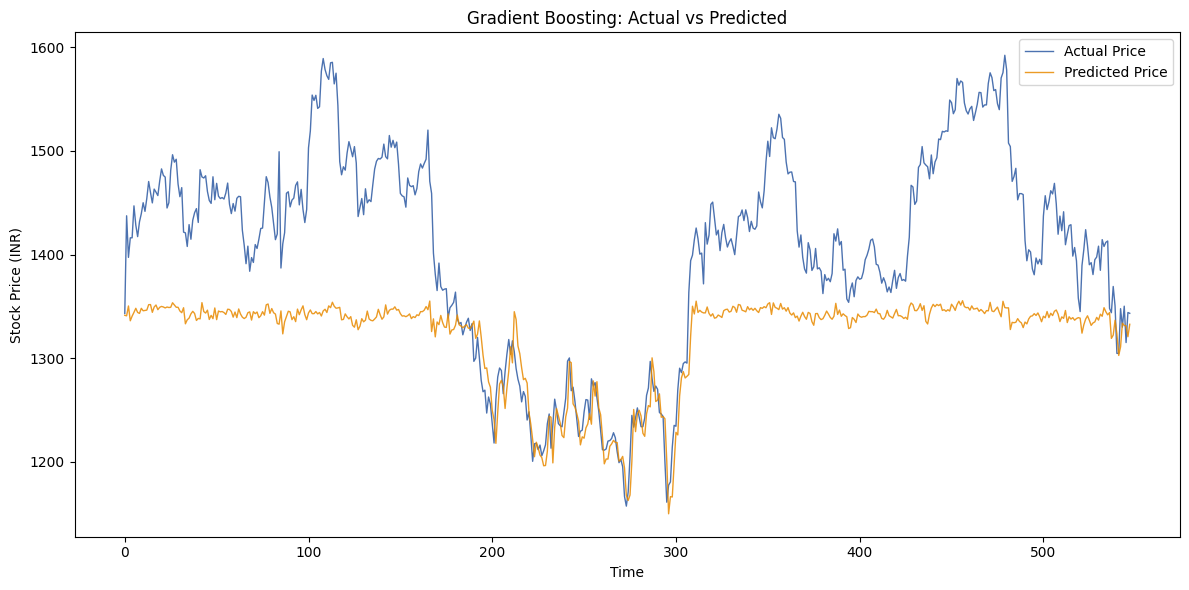

In [22]:
plt.figure(figsize=(12, 6))
plt.plot(y_test_gb.values,  label='Actual Price',    color='#4C72B0', linewidth=1)
plt.plot(y_pred_gb.values,  label='Predicted Price', color='#E88A00', linewidth=1, alpha=0.85)
plt.title('Gradient Boosting: Actual vs Predicted')
plt.xlabel('Time')
plt.ylabel('Stock Price (INR)')
plt.legend()
plt.tight_layout()
plt.savefig(
    'stock_datasets/gb_actual_vs_predicted.png',
    dpi=150, bbox_inches='tight'
)
plt.show()

### LSTM (Inverse Transformed — INR Scale)

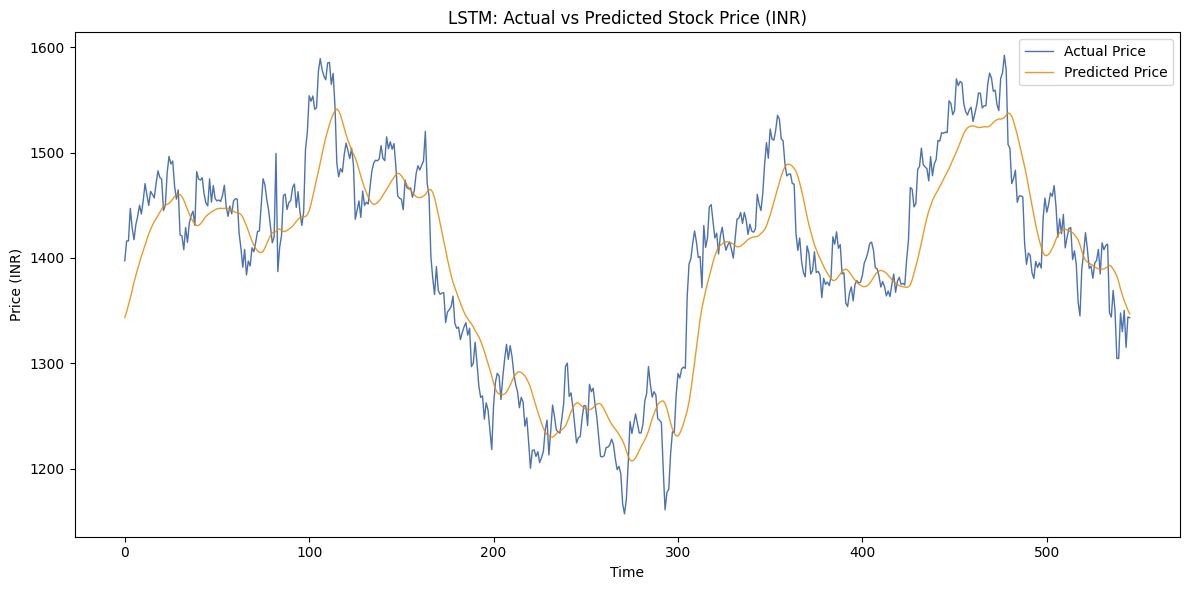

In [23]:
plt.figure(figsize=(12, 6))
plt.plot(y_test_lstm,  label='Actual Price',    color='#4C72B0', linewidth=1)
plt.plot(y_pred_lstm,  label='Predicted Price', color='#E88A00', linewidth=1, alpha=0.85)
plt.title('LSTM: Actual vs Predicted Stock Price (INR)')
plt.xlabel('Time')
plt.ylabel('Price (INR)')
plt.legend()
plt.tight_layout()
plt.savefig(
    'stock_datasets/lstm_actual_vs_predicted.png',
    dpi=150, bbox_inches='tight'
)
plt.show()

## STEP 17 — Save Evaluation Results

In [24]:
final_table.to_csv(
    'stock_datasets/model_evaluation_results.csv',
    index=False
)
print('Evaluation results saved.')
print(final_table.to_string(index=False))

Evaluation results saved.
            Model     RMSE     MAE  R2 Score  Accuracy  Precision  Recall
Linear Regression  19.3581 13.9915    0.9612    0.4881     0.4948  0.6884
    Random Forest 107.1756 86.4996   -0.1906    0.4918     0.4853  0.1196
Gradient Boosting 104.7681 84.9303   -0.1377    0.4899     0.4651  0.0725
             LSTM  40.7909 32.7967    0.8280    0.5229     0.5330  0.4400
 Baseline (Naive)  19.1787 13.8168    0.9619    0.4963     0.0000  0.0000


## STEP 18 — Model Ranking Summary

In [25]:
print('=' * 62)
print('MODEL RANKING SUMMARY')
print('=' * 62)

print('\nBy R2 Score (higher = better):')
for i, row in final_table.sort_values('R2 Score', ascending=False).iterrows():
    print(f'  {row["Model"]:<25}  R2       = {row["R2 Score"]:>7.4f}')

print('\nBy RMSE (lower = better):')
for i, row in final_table.sort_values('RMSE').iterrows():
    print(f'  {row["Model"]:<25}  RMSE     = {row["RMSE"]:>8.4f} INR')

print('\nBy Direction Accuracy (higher = better):')
for i, row in final_table.sort_values('Accuracy', ascending=False).iterrows():
    beat = 'beats baseline' if row['Accuracy'] > 0.50 else 'below baseline'
    print(f'  {row["Model"]:<25}  Accuracy = {row["Accuracy"]:>6.4f}  ({beat})')

print('\nConclusion:')
best_r2   = final_table.loc[final_table['R2 Score'].idxmax(), 'Model']
best_rmse = final_table.loc[final_table['RMSE'].idxmin(),     'Model']
best_acc  = final_table.loc[final_table['Accuracy'].idxmax(), 'Model']
print(f'  Best R2 Score  : {best_r2}')
print(f'  Lowest RMSE    : {best_rmse}')
print(f'  Best Direction : {best_acc}')
print('=' * 62)

MODEL RANKING SUMMARY

By R2 Score (higher = better):
  Baseline (Naive)           R2       =  0.9619
  Linear Regression          R2       =  0.9612
  LSTM                       R2       =  0.8280
  Gradient Boosting          R2       = -0.1377
  Random Forest              R2       = -0.1906

By RMSE (lower = better):
  Baseline (Naive)           RMSE     =  19.1787 INR
  Linear Regression          RMSE     =  19.3581 INR
  LSTM                       RMSE     =  40.7909 INR
  Gradient Boosting          RMSE     = 104.7681 INR
  Random Forest              RMSE     = 107.1756 INR

By Direction Accuracy (higher = better):
  LSTM                       Accuracy = 0.5229  (beats baseline)
  Baseline (Naive)           Accuracy = 0.4963  (below baseline)
  Random Forest              Accuracy = 0.4918  (below baseline)
  Gradient Boosting          Accuracy = 0.4899  (below baseline)
  Linear Regression          Accuracy = 0.4881  (below baseline)

Conclusion:
  Best R2 Score  : Baseline (Naive